In [2]:
import importlib, itertools
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import plot_res
importlib.reload( plot_res )
import plot_res as p

<AxesSubplot:xlabel='Time[s]', ylabel='ReTX'>

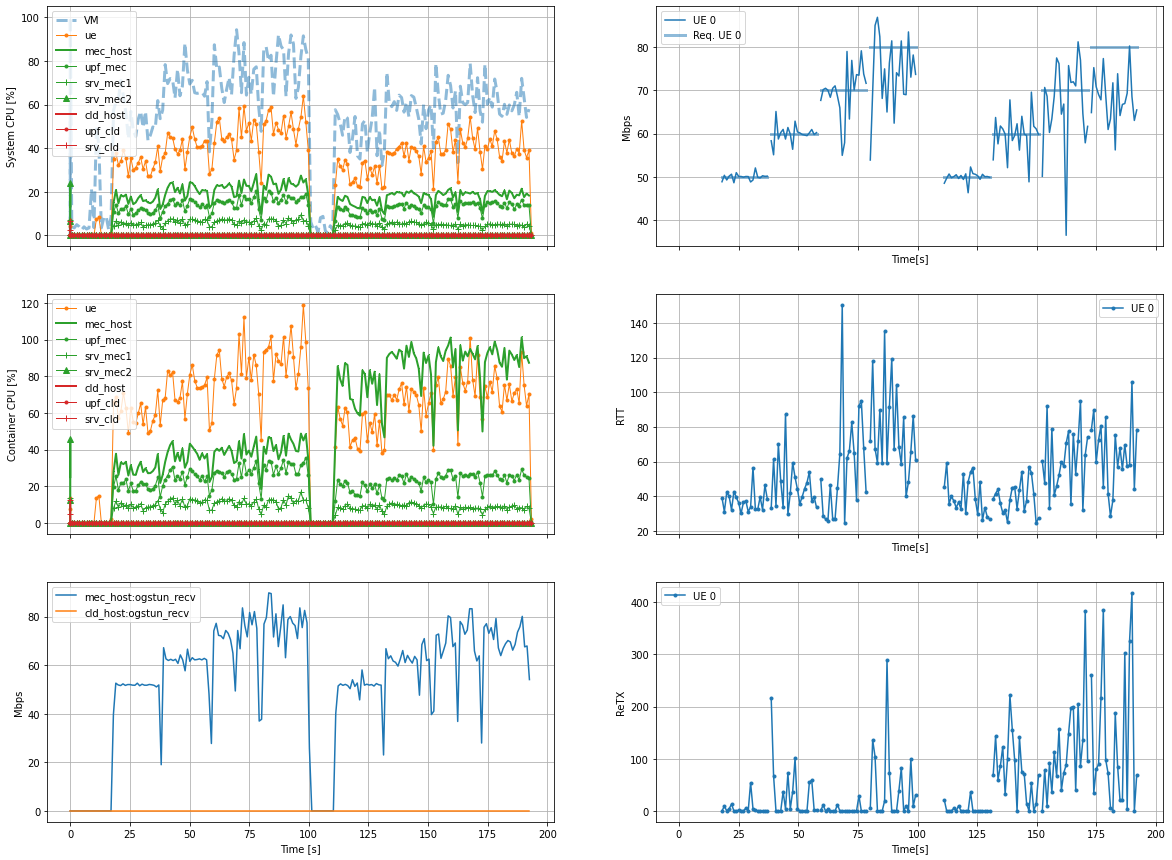

In [46]:
fig, ax = plt.subplots(nrows=3, ncols=2, sharex=True , figsize=(20,15) )

res = p.load_results_json( f'../results/Test_scenario0_iperf_bbr.json' )

p.plot_raw_cont_sys_cpu( res, ax[0][0], scen_idx=2)
p.plot_raw_cont_cpu(     res, ax[1][0], scen_idx=2)
p.plot_raw_upf_thr(      res, ax[2][0])

p.plot_raw_iperf_tcp_mbps_PerUe( res, ax[0][1] , ue="*", colors=p.get_color_list() )
p.plot_raw_iperf_tcp_rtt_PerUe(  res, ax[1][1] , ue="*", colors=p.get_color_list() )
p.plot_raw_iperf_tcp_retx_PerUe( res, ax[2][1] , ue="*", colors=p.get_color_list() )



(0.0, 300.0)

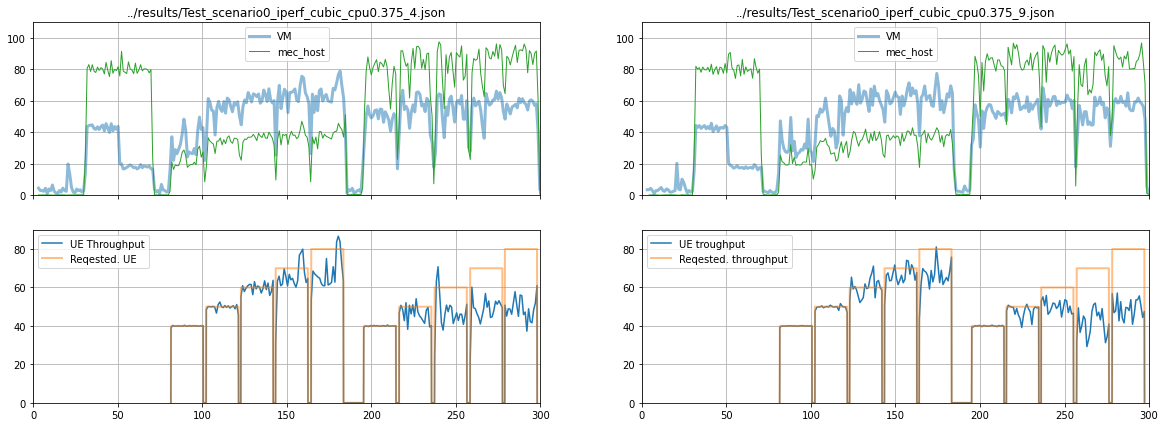

In [15]:
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True , figsize=(20,7) )

# file = '../results/Test_scenario0_iperf_cubic_cpu0.5.json'
file = '../results/Test_scenario0_iperf_cubic_cpu0.375_4.json'
# file = '../results/Test_scenario0_iperf_reno.json'
# file = '../results/Test_scenario0_iperf_bbr.json'
ax[0][0].set_title( file )
res = p.load_results_json( file )
time,thr,req = p.plot_raw_iperf_tcp_get_thrPerUeAllSessions( res, ue=0)
ax[0][0].plot( res["cpu"]["sys"]["time"][4:-1] , res["cpu"]["sys"]["cpu_perc"][4:-1] , label="VM" , alpha=0.5, lw=3  )
ax[0][0].plot( res["cpu"]["mec_host"]["time"][4:-1] , res["cpu"]["mec_host"]["cpu_perc"][4:-1] , label="mec_host" , color="C2" , marker="" , lw=1)
# ax[0][0].plot( res["cpu"]["ue"]["time"] , res["cpu"]["ue"]["cpu_perc"] , label="UE" , color="C1" , marker="" , lw=1)
# p.plot_raw_iperf_tcp_mbps_PerUe( res, ax[1][0] , ue="*", colors=p.get_color_list() )
ax[1][0].plot(  time , thr , color="C0" , label=f'UE Throughput'     )
ax[1][0].plot(  time , req , color="C1" , label=f'Reqested. UE', alpha=0.5, lw=2 )

file = '../results/Test_scenario0_iperf_cubic_cpu0.375_9.json'
ax[0][1].set_title( file )
res = p.load_results_json( file )
time,thr,req = p.plot_raw_iperf_tcp_get_thrPerUeAllSessions( res, ue=0 )
ax[0][1].plot( res["cpu"]["sys"]["time"][4:-1] , res["cpu"]["sys"]["cpu_perc"][4:-1] , label="VM" , alpha=0.5, lw=3  )
ax[0][1].plot( res["cpu"]["mec_host"]["time"][4:-1] , res["cpu"]["mec_host"]["cpu_perc"][4:-1] , label="mec_host" , color="C2" , marker="" , lw=1)
# ax[0][1].plot( res["cpu"]["ue"]["time"] , res["cpu"]["ue"]["cpu_perc"] , label="UE" , color="C1" , marker="" , lw=1)
# p.plot_raw_iperf_tcp_mbps_PerUe( res, ax[1][1] , ue="*", colors=p.get_color_list() )
ax[1][1].plot(  time , thr , color="C0" , label=f'UE troughput'     )
ax[1][1].plot(  time , req , color="C1" , label=f'Reqested. throughput', alpha=0.5, lw=2 )

ax[0][0].legend( )
ax[0][1].legend( )
ax[1][0].legend( )
ax[1][1].legend( )
ax[0][0].grid(visible=True)
ax[0][1].grid(visible=True)
ax[1][0].grid(visible=True)
ax[1][1].grid(visible=True)
ax[0][0].set_ylim(0,110)
ax[0][1].set_ylim(0,110)
ax[1][0].set_ylim(0,90)
ax[1][1].set_ylim(0,90)
ax[0][1].set_xlim(0,300)
